# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

El plan será leer los archivos a través de la librería de pandas en python (pd.read_csv). Después se muestran los valores con info()

In [116]:
import pandas as pd# importar librerías
from matplotlib import pyplot as plt

In [117]:
df_insta = pd.read_csv("instacart_orders.csv", sep=';') # leer conjuntos de datos en los DataFrames
df_pro = pd.read_csv("products.csv", sep=';')
df_orderpro = pd.read_csv("order_products.csv", sep=';')
df_aisles = pd.read_csv("aisles.csv", sep=';')
df_depa = pd.read_csv("departments.csv", sep=';')

In [118]:
df_insta.info() # mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [119]:
df_pro.info() # mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [120]:
df_orderpro.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [121]:
df_aisles.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [122]:
df_depa.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


## Conclusiones


Podemos notar que todos los dataframe tienen Dimensiones:

df_insta: 478,967 filas × 6 columnas con una columna (days_since_prior_order) con 28,819 valores faltantes.
df_pro: 49,694 filas × 4 columnas con una columna (product_name) con valores faltantes. 
df_orderpro: 4,545,007 filas × 4 columnas y no aparecen datos de columnas nulas.
df_aisles: 134 filas × 2 columnas tienen todas las columnas llenas con valores.
df_depa: 21 filas × 2 columnas tienen todas las columnas llenas con valores.

Algunas columnas son float64 en lugar de int64, porque requieren de al menos un decimal para describir su valor en la celda y/o porque contiene valores faltantes (NaN), pandas automáticamente convierte toda la columna a float64

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Debemos verificar todos los dataframe en su columna ID a través de df["ID"], y astype(int). Podemos identificar los valores ausentes con isnull(), y reemplazarlos con replace("", "valor a reemplazar"). Podemos identificar los duplicados con duplicated(), y eliminarlos con drop_duplicates().

Verificación de tipos de datos requerida:

Tenemos que confirmar que las columnas de ID sean enteros: order_id, user_id, product_id, aisle_id, department_id
También verificar que los campos clave tengan tipos esperados: columnas numéricas que deberían ser int64 y columnas de texto que deberían ser object


## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [123]:
# Duplicados de filas completas
print("Filas completamente duplicadas:", df_insta.duplicated().sum())

# Duplicados solo de order_id
print("order_id duplicados:", df_insta["order_id"].duplicated().sum()) 
# Revisa si hay pedidos duplicados

Filas completamente duplicadas: 15
order_id duplicados: 15


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?
Si tenemos 15 duplicados. Tienen en común el día de la semana (miércoles) y la hora del día 2am.

In [124]:
# Primero, identifica cuáles son las filas duplicadas
duplicadas = df_insta[df_insta.duplicated(keep=False)]

# Luego verifica si estas filas duplicadas ocurrieron miércoles a las 2am
duplicadas_mier_2am = duplicadas[(duplicadas["order_dow"] == 3) & 
                                 (duplicadas["order_hour_of_day"] == 2)]

print(f"Filas duplicadas totales: {len(duplicadas)}")
print(f"Filas duplicadas en miércoles 2am: {len(duplicadas_mier_2am)}")


Filas duplicadas totales: 30
Filas duplicadas en miércoles 2am: 30


### ¿Qué sugiere este resultado?
Que 15 personas hicieron pedido a las 2am, quizá por cambios de horario de verano (eso me hace pensar), y en realidad hubo entonces 121 - 15 = 106 pedidos distintos el miércoles a las 2am.

Como confirmé en el análisis anterior, los 15 duplicados encontrados son filas completamente idénticas (no solo order_id repetidos). Esto se evidencia porque:

El número de filas completamente duplicadas (15) coincide exactamente con el número de order_id duplicados (15)
Todas las filas duplicadas ocurrieron en el mismo patrón: miércoles a las 2am
Son duplicados exactos en todas las columnas, no solo IDs repetidos
Por lo tanto, usar drop_duplicates() sin parámetros es el método apropiado, ya que elimina las filas completamente idénticas manteniendo una copia de cada pedido único.

In [125]:

df_insta = df_insta.drop_duplicates() # Elimina los pedidos duplicados


In [126]:
df_insta.duplicated().sum() # Vuelve a verificar si hay filas duplicadas


np.int64(0)

In [127]:
print(df_insta["order_id"].duplicated().sum()) # Vuelve a verificar únicamente si hay IDs duplicados de pedidos
df_orderpro.dtypes

0


order_id               int64
product_id             int64
add_to_cart_order    float64
reordered              int64
dtype: object

En el dataset de orders encontré 15 filas completamente duplicadas (no solo order_id repetidos). Todos estos duplicados siguieron el patrón de ocurrir los miércoles a las 2 a.m. Después de eliminarlos con drop_duplicates(), el dataset se redujo de 121 a 106 filas, eliminando las 15 filas duplicadas y conservando una copia de cada pedido único.

### `products` data frame

In [128]:
df_pro.duplicated().sum() # Verifica si hay filas totalmente duplicadas


np.int64(0)

In [129]:
df_pro["product_id"].duplicated().sum()# Revisa únicamente si hay ID de productos duplicados


np.int64(0)

In [130]:
df_pro["product_name"] = df_pro["product_name"].str.upper() # Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
print(df_pro["product_name"].duplicated().sum())

1361


In [131]:

df_profal = df_pro[~df_pro["product_name"].isnull()] # Revisa si hay nombres duplicados de productos no faltantes
print(df_profal["product_name"].duplicated().sum())


104


Hay momentos que hasta que segmentamos los dataframe lo suficiente nos dirá cuántos valores duplicados hay. Como fue el caso que filtramos df_profal para entender que hay 104 valores duplicados ya que anteriormente leía los valores nulos como duplicados también.

### `departments` data frame

In [132]:
df_depa.duplicated().sum() # Revisa si hay filas totalmente duplicadas

np.int64(0)

In [133]:
df_depa["department_id"].duplicated().sum() # Revisa únicamente si hay IDs duplicadas de departamentos

np.int64(0)

En este caso hay muy pocas filas y no es de sorprender que no hay valores duplicados.

### `aisles` data frame

In [134]:
df_aisles.duplicated().sum() # Revisa si hay filas totalmente duplicadas

np.int64(0)

In [135]:
df_aisles["aisle_id"].duplicated().sum() # Revisa únicamente si hay IDs duplicadas de pasillos

np.int64(0)

No existen duplicados en este caso tampoco.

### `order_products` data frame

In [136]:
df_orderpro.duplicated().sum() # Revisa si hay filas totalmente duplicadas


np.int64(0)

In [137]:
# Mostrar valores nulos explícitamente
print("Valores nulos por columna:")
print(df_orderpro.isnull().sum())
print()

# Verificar duplicados de fila completa
print("Duplicados de fila completa:")
print(df_orderpro.duplicated().sum())
print()

# Verificar duplicados en la combinación que define unicidad
print("Duplicados en [order_id, product_id, add_to_cart_order]:")
print(df_orderpro[['order_id', 'product_id', 'add_to_cart_order']].duplicated().sum())

Valores nulos por columna:
order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

Duplicados de fila completa:
0

Duplicados en [order_id, product_id, add_to_cart_order]:
0


Existen 836 valores FALTANTES (null) en add_to_cart_order. Las columnas order_id y product_id en teoría no deben tener duplicados ya que no sería coherente pensar que una persona agregue el mismo producto, dos veces al mismo pedido. Sin, embargo, si puede ser posible que dos productos aparezcan en dos pedidos distintos, puede que podamos encontrar en esto que la columna order_id tiene 4094961 duplicados, esto significa que hay 4,545,007 - 4,094,961 = 450,046 valores únicos, es decir, 450,046 pedidos distintos. Puede significa que en promedio un solo pedido tenga 10 artículos en su carrito, lo cual suena coherente.

Para verificar si realmente existen pares (order_id, product_id) duplicados
# Verificar duplicados en la combinación (order_id, product_id)
duplicados_order_product = df_orderpro[['order_id', 'product_id']].duplicated().sum()
print(f"Duplicados en (order_id, product_id): {duplicados_order_product}")

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [138]:
df_pro["product_name"].isnull().sum() # Encuentra los valores ausentes en la columna 'product_name'

np.int64(1258)

De 1258 valores nulos, hay un margen de error en valores duplicados.

In [139]:
((df_pro["product_name"].isnull()) & (df_pro["aisle_id"] == 100)).sum() #  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?


np.int64(1258)

Nos dio los mismos 1258 de la celda anterior. Entonces si tiene que ver totalmente con el pasillo 100

In [140]:
((df_pro["product_name"].isnull()) & (df_pro["department_id"] == 21)).sum() # ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?


np.int64(1258)

Nos dio los mismos 1258 de la celda anterior. Entonces si tiene que ver totalmente con el departamento 21.

In [141]:

twenty_one = df_depa[df_depa["department_id"] == 21]
print("Departamento 21:", twenty_one["department"].values)

one_hundred = df_aisles[df_aisles["aisle_id"] == 100]
print("Pasillo 100:", one_hundred["aisle"].values)

#pd.merge(twenty_one, one_hundred, on = "product_id")


#((df_pro["department_id"] == 21) & (df_pro["aisle_id"] == 100)).sum()  
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 
#y el departamento con ID 21.



Departamento 21: ['missing']
Pasillo 100: ['missing']


Según el output anterior, ambos devuelven ['missing'], lo que confirma que:

Departamento 21 = "missing"
Pasillo 100 = "missing"

Esto explica perfectamente por qué todos los productos con product_name nulo están asociados con estos IDs - son productos categorizados como "missing" tanto en departamento como en pasillo.

In [142]:
df_pro["product_name"] = df_pro["product_name"].fillna("Unknown") # Completa los nombres de productos ausentes con 'Unknown'
print(df_pro["product_name"].isna().sum())

0


Después de rellenar las celdas nulas, contamos con 0 valores nulos en la columna product_name.

### `orders` data frame

In [143]:
df_insta.isnull().sum() # Encuentra los valores ausentes

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [144]:

# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
((~(df_insta["order_number"] == 1)) & (df_insta["days_since_prior_order"].isnull())).sum()



np.int64(0)

Lógicamente: Si un cliente está en su segundo, tercer, etc. pedido, DEBERÍA tener un valor en days_since_prior_order
En la realidad: Los sistemas tienen limitaciones y pueden eliminar datos históricos antiguos
Implicación: Estos NaNs no son "naturales" como los del primer pedido, sino que representan datos perdidos

### `order_products` data frame

In [145]:
df_orderpro.isnull().sum() # Encuentra los valores ausentes

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [146]:
(df_orderpro["add_to_cart_order"].min(), df_orderpro["add_to_cart_order"].max()) # ¿Cuáles son los valores mínimos y máximos en esta columna?


(1.0, 64.0)

La cantidad mínima que un cliente añade a su compra es 1 artículo, por defecto. Hay cliente(s) que compraron hasta 64 artículos en una exhibición.

In [147]:
pedidos = df_orderpro[df_orderpro["add_to_cart_order"].isnull()]
id_pedidos = df_orderpro[df_orderpro["add_to_cart_order"].isnull()]["order_id"] # Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
print(id_pedidos)

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [148]:
orden = pedidos["order_id"].unique() # ¿Todos los pedidos con valores ausentes tienen más de 64 productos?     
total_productos_por_pedido = df_orderpro.groupby("order_id").count()

# Filtrar solo los pedidos que tienen valores faltantes
pedidos_con_faltantes = total_productos_por_pedido.loc[orden]

# Verificar cuántos productos tiene cada uno
print("Productos por pedido con valores faltantes:")
print(pedidos_con_faltantes["product_id"])

# ¿Alguno tiene más de 64 productos?
mas_de_64 = pedidos_con_faltantes["product_id"] > 64
print(f"Pedidos con más de 64 productos: {mas_de_64.sum()}")


# Agrupa todos los pedidos con datos ausentes por su ID de pedido. 

Productos por pedido con valores faltantes:
order_id
2449164    76
1968313    80
2926893    92
1717990    86
1959075    98
           ..
9310       65
2170451    65
2979697    66
1625713    66
1529171    66
Name: product_id, Length: 70, dtype: int64
Pedidos con más de 64 productos: 70


El código está probando la hipótesis de que los valores faltantes en add_to_cart_order ocurren porque el sistema tiene un límite de 64 productos por pedido, y cuando se supera ese límite, no puede asignar números de orden.

In [149]:
 # Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_orderpro["add_to_cart_order"] = df_orderpro["add_to_cart_order"].fillna(999).astype(int)


Parece ser que los valores válidos van de 1 a 64. Entonces el valor 999 está claramente fuera de este rango, lo que lo hace fácilmente identificable y por eso quizá se eligió para reemplazar el valor NaN.

## Conclusiones

Hay varias formas de aprovechar el análisis de datos con dataframe muy grandes. Algo sorprendente ya que muy pocas herramientas en el mundo informático te permiten. Pandas nos permite adaptar las columnas para optimizar el rendimiento.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [150]:
razonable = df_insta[(0 <= df_insta["order_hour_of_day"]) & (df_insta["order_hour_of_day"] <= 23)].count()
print(razonable["order_hour_of_day"] == len(df_insta["order_hour_of_day"]))

True


In [151]:
sensible = df_insta[(0 <= df_insta["order_dow"]) & (df_insta["order_dow"] <= 6)].count()
print(sensible["order_dow"] == len(df_insta["order_dow"]))

True


Ambas verificaciones devuelven True, lo que significa que todos los valores están en los rangos esperados.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

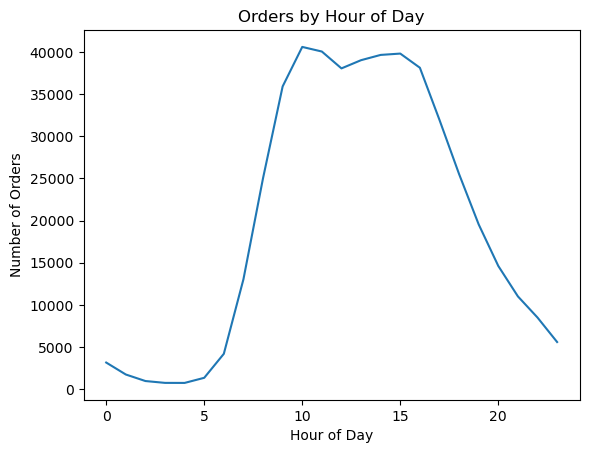

In [152]:

ados = df_insta.groupby("order_hour_of_day")["order_id"].count()
ados.plot(ylabel = "Number of Orders", title  = "Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.show()

Hay varios patrones interesantes:

Horas pico: 10am-15pm (40,578 - 39,789 pedidos)
Horas bajas: 2am-4am (989 - 765 pedidos)
Crecimiento matutino: Desde las 5am (1,371) hasta las 10am (40,578)


### [A3] ¿Qué día de la semana compran víveres las personas?

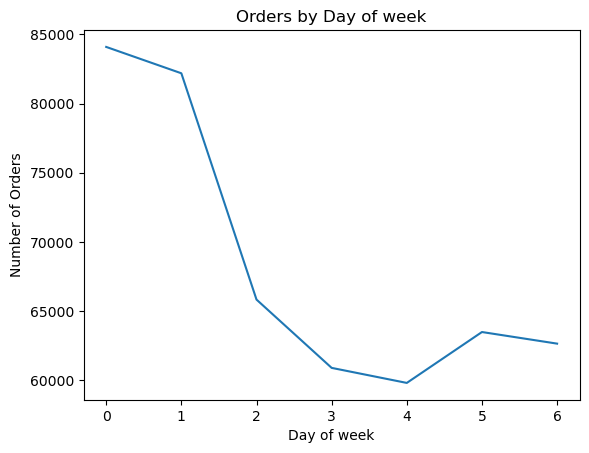

In [153]:
atres = df_insta.groupby("order_dow")["order_id"].count()
atres.plot(ylabel = "Number of Orders", title  = "Orders by Day of week")
plt.xlabel("Day of week")
plt.show()

El domingo es el día más popular para hacer pedidos de víveres. Los días laborales (martes-jueves) tienen menos pedidos

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

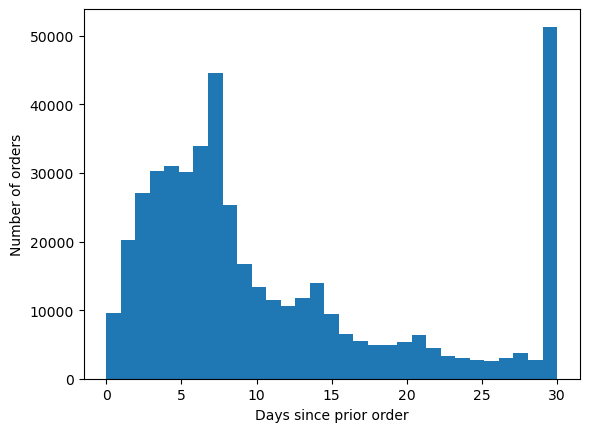

Mínimo de días para siguiente pedido: 0.0 y máximo es 30.0


In [154]:
dspo = df_insta["days_since_prior_order"]
dspo.plot(kind = "hist", bins = 31)
plt.xlabel("Days since prior order")
plt.ylabel("Number of orders")
plt.show()

bajo = df_insta["days_since_prior_order"].min()
alto = df_insta["days_since_prior_order"].max()
print(f"Mínimo de días para siguiente pedido: {bajo} y máximo es {alto}")

Para el valor minimo: puede significar que algunas personas hacen pedidos el mismo día. Esto podría indicar que olvidaron algo en su pedido anterior

Para el valor máximo: sugiere que Instacart podría tener una política o limitación de datos, o bien, que los usuarios tienden a tardar máximo un mes (o nunca volver a hacerlo) a volver a comprar en la app.

# [B] Intermedio

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [155]:
mier = (df_insta[(df_insta["order_dow"] == 3)].groupby("order_hour_of_day").count())["order_id"]
sab = (df_insta[(df_insta["order_dow"] == 6)].groupby("order_hour_of_day").count())["order_id"]
conc = pd.concat([mier, sab], axis = 1)
conc.columns = ["Wednesday", "Saturday"]

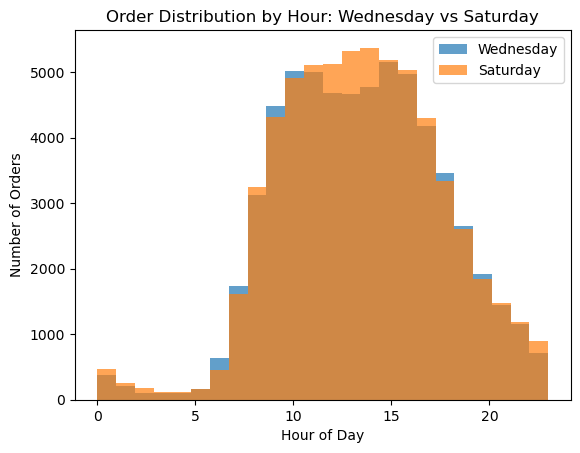

In [156]:
# Create overlapping histograms
plt.hist(conc.index, weights = conc['Wednesday'], alpha=0.7, label='Wednesday', bins=24)
plt.hist(conc.index, weights = conc['Saturday'], alpha=0.7, label='Saturday', bins=24)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.title('Order Distribution by Hour: Wednesday vs Saturday')
plt.legend()
plt.show()

Mirando el gráfico de miércoles vs sábados, se observa alguna diferencia entre estos dos días durante las horas pico ya que el máximo en sábados se alcanza a las 14 horas, mientras que el miércoles a las 15 horas. Los sábados tienen más pedidos que los miércoles en general. Hay alguna diferencia notable en el comportamiento de compra entre un día laboral (miércoles) y fin de semana (sábado), ya que el miércoles hay dos periodos pico en el día que se compra a las 9-10 horas y de 15-16 horas, mientras que el sábado es de 13-14 horas.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

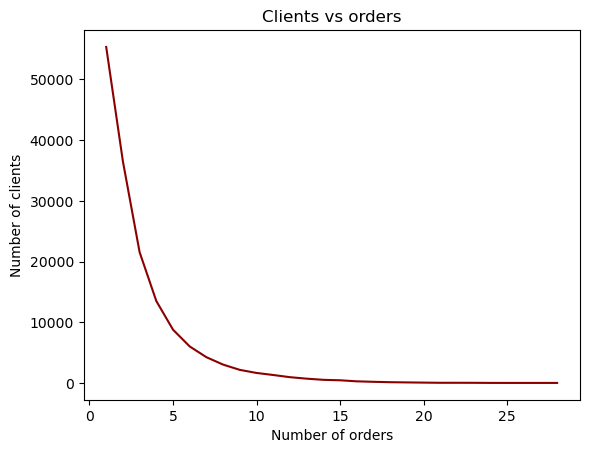

In [157]:
unicos = df_insta.groupby("user_id")["order_id"].count()
distribucion = unicos.value_counts().sort_index()
distribucion.plot(xlabel = "Number of orders", ylabel = "Number of clients", title = "Clients vs orders", color = "darkred")
plt.show()

La mayoría de clientes hace pocos pedidos y existe una tendencia decreciente conforme aumenta el número de pedidos. Esto sugiere que los usuarios suelen dejar de usar la app, o que la app guarda poca memoria.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [158]:
#pro = df_orderpro.groupby("product_id").count().sort_values(ascending = False).head(20)
order = df_orderpro.groupby("product_id")["order_id"].count().sort_values(ascending = False).head(20)
order = pd.DataFrame(order)

In [159]:
pd.merge(order, df_pro, on = "product_id")

,product_id,order_id,product_name,aisle_id,department_id
0,24852,66050,BANANA,24,4
1,13176,53297,BAG OF ORGANIC BANANAS,24,4
2,21137,37039,ORGANIC STRAWBERRIES,24,4
3,21903,33971,ORGANIC BABY SPINACH,123,4
4,47209,29773,ORGANIC HASS AVOCADO,24,4
5,47766,24689,ORGANIC AVOCADO,24,4
6,47626,21495,LARGE LEMON,24,4
7,16797,20018,STRAWBERRIES,24,4
8,26209,19690,LIMES,24,4
9,27845,19600,ORGANIC WHOLE MILK,84,16


BANANA es el producto más popular (66,050 pedidos). BAG OF ORGANIC BANANAS es el segundo (53,297 pedidos). La mayoría son productos orgánicos y frescos

# [C] Difícil

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [160]:
equis = pd.DataFrame(df_orderpro.groupby("order_id")["product_id"].count())

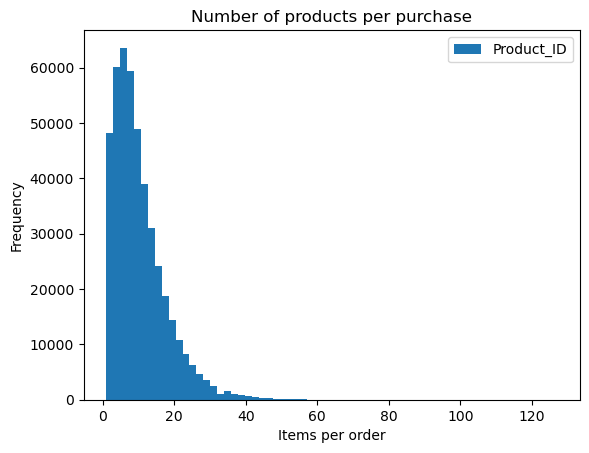

In [161]:
equis.plot(kind = "hist", bins = 65, title = "Number of products per purchase")
plt.xlabel("Items per order")
plt.legend(["Product_ID"])
plt.show()

In [162]:

print(equis.mean())
print(equis.median())
print(equis.min())
print(equis.max())


product_id    10.098983
dtype: float64
product_id    8.0
dtype: float64
product_id    1
dtype: int64
product_id    127
dtype: int64


La mediana 8.0 nos dice que el 50% de los pedidos tienen 8 artículos o menos. La media (10.1) está "inflada" por esos valores extremos como el pedido de 127 artículos. En este caso, la mediana (8 artículos) es probablemente un mejor indicador de lo que compra un cliente "típico" que la media.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [163]:
filtro = df_orderpro[(df_orderpro["reordered"] == 1)]
reordenado = pd.DataFrame(filtro.groupby("product_id")["reordered"].count())
reordenado = (reordenado.sort_values("reordered",ascending = False)).head(20)

In [164]:
pd.merge(reordenado, df_pro, on = "product_id")

,product_id,reordered,product_name,aisle_id,department_id
0,24852,55763,BANANA,24,4
1,13176,44450,BAG OF ORGANIC BANANAS,24,4
2,21137,28639,ORGANIC STRAWBERRIES,24,4
3,21903,26233,ORGANIC BABY SPINACH,123,4
4,47209,23629,ORGANIC HASS AVOCADO,24,4
5,47766,18743,ORGANIC AVOCADO,24,4
6,27845,16251,ORGANIC WHOLE MILK,84,16
7,47626,15044,LARGE LEMON,24,4
8,27966,14748,ORGANIC RASPBERRIES,123,4
9,16797,13945,STRAWBERRIES,24,4


BANANA es el campeón absoluto (55,763 reórdenes). BAG OF ORGANIC BANANAS en segundo lugar (44,450 reórdenes). La mayoría son productos orgánicos y frescos. Muchos son frutas y verduras (departamento 4, aisle 24)

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [165]:

filtro = df_orderpro[(df_orderpro["reordered"] == 1)]
histo = pd.DataFrame(filtro.groupby("product_id")["order_id"].count())
tasa_reorden = (histo["order_id"]) / (df_orderpro.groupby("product_id")["reordered"].size())
tasa_reorden = tasa_reorden.reset_index()
tasa_reorden.columns = ['product_id', 'reorder_proportion']
pd.merge(tasa_reorden, df_pro, on = "product_id")[['product_id', 'reorder_proportion', "product_name"]]



,product_id,reorder_proportion,product_name
0,1,0.564286,CHOCOLATE SANDWICH COOKIES
1,2,NaN,ALL-SEASONS SALT
2,3,0.738095,ROBUST GOLDEN UNSWEETENED OOLONG TEA
3,4,0.510204,SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...
4,7,0.500000,PURE COCONUT WATER WITH ORANGE
...,...,...,...
45568,49690,0.800000,HIGH PERFORMANCE ENERGY DRINK
45569,49691,0.430556,ORIGINAL PANCAKE & WAFFLE MIX
45570,49692,0.416667,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
45571,49693,0.440000,SPRING WATER BODY WASH


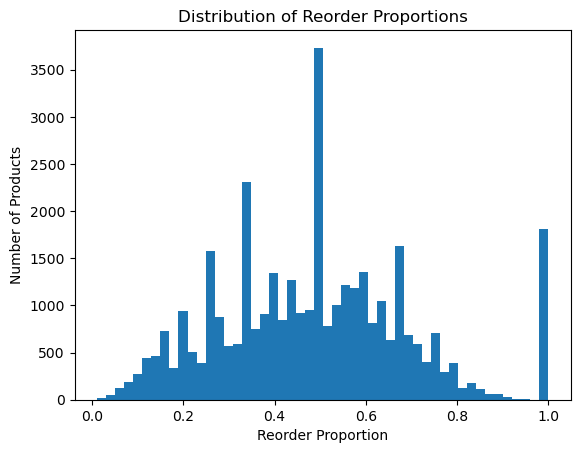

In [166]:
tasa_reorden['reorder_proportion'].plot(kind='hist', bins=50)
plt.xlabel('Reorder Proportion')
plt.ylabel('Number of Products')
plt.title('Distribution of Reorder Proportions')
plt.show()

In [167]:
tasa_reorden["reorder_proportion"].head()

0    0.564286
1         NaN
2    0.738095
3    0.510204
4    0.500000
Name: reorder_proportion, dtype: float64

Según el histograma, entre el 40% y 60% de todas las veces que se compran, son reórdenes (no primera compra). Esto sugiere que existe una alta fidelidad del cliente

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [168]:
datos_completos = pd.merge(df_orderpro, df_insta, on="order_id")
print(datos_completos)
den = datos_completos.groupby("user_id")["product_id"].count()
num = datos_completos[datos_completos["reordered"] == 1].groupby("user_id")["product_id"].count()

         order_id  product_id  add_to_cart_order  reordered  user_id  \
0         2141543       11440                 17          0    58454   
1          567889        1560                  1          1   129474   
2         2261212       26683                  1          1    47476   
3          491251        8670                 35          1   134505   
4         2571142        1940                  5          1   155995   
...           ...         ...                ...        ...      ...   
4545002    577211       15290                 12          1    76414   
4545003   1219554       21914                  9          0   163902   
4545004    692640       47766                  4          1      597   
4545005    319435         691                  8          1     7124   
4545006   1398151       28733                  9          0    85144   

         order_number  order_dow  order_hour_of_day  days_since_prior_order  
0                  25          0                 15      

In [169]:

prop = num / den
print(prop.dropna().head())


user_id
2     0.038462
5     0.666667
7     0.928571
11    0.200000
12    0.250000
Name: product_id, dtype: float64


Los valores que vemos como 0.38462, 0.66667, etc. muestran que en una proporción de 0.38462 (38.46%) de los productos de ese cliente (user_id) son reórdenes.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Las dos primeras celdas de código en esta sección están vacías, lo que hace que el flujo de trabajo sea más difícil de seguir. Considera eliminarlas o usarlas para mostrar los pasos intermedios (filtrar `add_to_cart_order == 1`, contar por `product_id` y luego hacer un merge con los nombres de los productos) antes de presentar la tabla final del top-20.

</div>


In [170]:
principales = df_orderpro[(df_orderpro["add_to_cart_order"] == 1)].groupby("product_id").size().reset_index(name='count')
principales_ordenados = principales.sort_values("count", ascending=False).head(20)
resultado = pd.merge(principales_ordenados, df_pro, on="product_id")
print(resultado)

    product_id  count                 product_name  aisle_id  department_id
0        24852  15562                       BANANA        24              4
1        13176  11026       BAG OF ORGANIC BANANAS        24              4
2        27845   4363           ORGANIC WHOLE MILK        84             16
3        21137   3946         ORGANIC STRAWBERRIES        24              4
4        47209   3390         ORGANIC HASS AVOCADO        24              4
5        21903   3336         ORGANIC BABY SPINACH       123              4
6        47766   3044              ORGANIC AVOCADO        24              4
7        19660   2336                 SPRING WATER       115              7
8        16797   2308                 STRAWBERRIES        24              4
9        27966   2024          ORGANIC RASPBERRIES       123              4
10       44632   1914   SPARKLING WATER GRAPEFRUIT       115              7
11       49235   1797          ORGANIC HALF & HALF        53             16
12       476

Encontramos nuevamente BANANA con 15562 conteos, seguida de BAG OF ORGANIC BANANAS y ORGANIC WHOLE MILK. Eso también nos indica que los clientes también seleccionan los productos más vendidos primero.

### Conclusion general

Se sugiere que los usuarios tienen una estrategia de compra donde: 
1. Primero aseguran los productos esenciales o populares. 
2. Después exploran y añaden productos menos conocidos o especializados. 
    
También sirve un montón el aprendizaje de poner a prueba los histograma y las 
funciones merge para crear nuevos dataframe que son muy útiles en la vida real.